In [12]:
%load_ext autoreload
%autoreload 2

import os
import json
import torch
import pandas as pd
import numpy as np
import optuna
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from model_definition import CNN1DClassifier

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data analysis

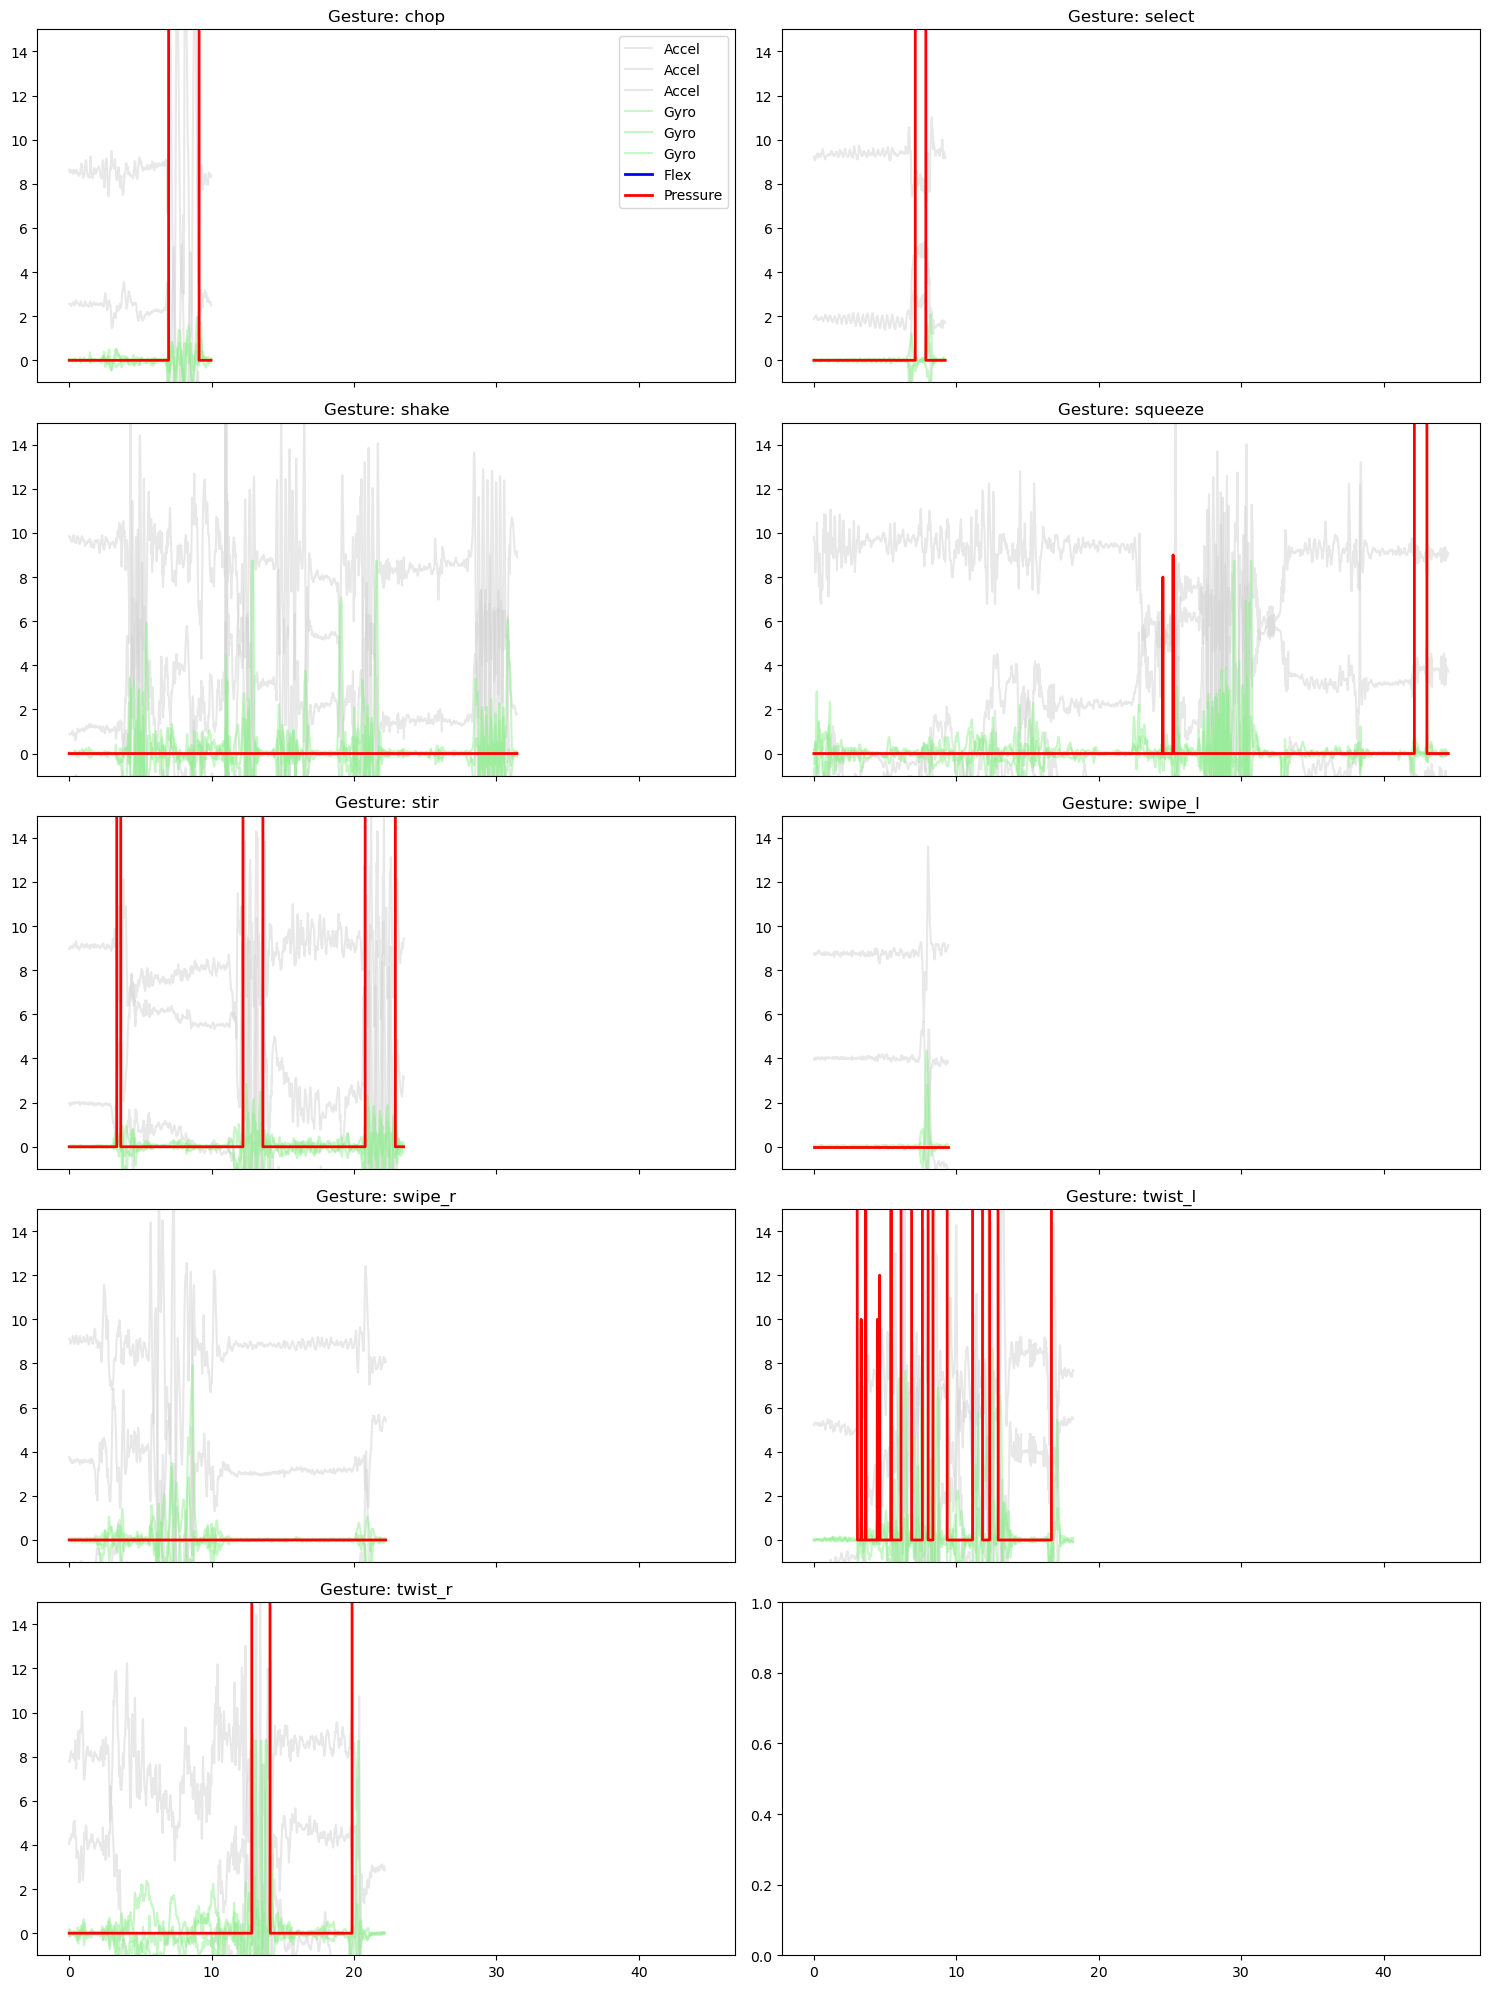

In [ ]:
# VERIFY RAW SENSOR DATA

def plot_gesture_comparison(data_path, labels_dict):
    fig, axes = plt.subplots(5, 2, figsize=(15, 20), sharex=True)
    axes = axes.flatten()
    
    for i, filepath in enumerate(labels_dict.keys()):
        gesture_name = filepath.rsplit("_", 1)[0]
        file_path = os.path.join(data_path, filepath)
        df = pd.read_csv(file_path, header=None)
        
        time = (df[0] - df[0].iloc[0]) / 1000.0

        ax = axes[i]
        ax.plot(time, df.iloc[:, 1:4], color='lightgrey', alpha=0.5, label='Accel' if i==0 else "")
        ax.plot(time, df.iloc[:, 4:7], color='lightgreen', alpha=0.5, label='Gyro' if i==0 else "")
        ax.plot(time, df.iloc[:, 7], color='blue', linewidth=2, label='Flex' if i==0 else "")
        ax.plot(time, df.iloc[:, 8], color='red', linewidth=2, label='Pressure' if i==0 else "")
        
        ax.set_title(f"Gesture: {gesture_name}")
        ax.set_ylim([-1, 15])           # ignores flex, since that's so high up
        if i == 0: 
            ax.legend()

    plt.tight_layout()
    plt.show()

test_dict = {
    "chop_1.txt": 0,
    "select_1.txt": 1,
    "shake_1.txt": 2,
    "squeeze_1.txt": 3,
    "stir_1.txt": 4,
    "swipe_l_1.txt": 5,
    "swipe_r_1.txt": 6,
    "twist_l_1.txt": 7,
    "twist_r_1.txt": 8
}
plot_gesture_comparison("training_dataset_clean", test_dict)

### Cleaned data processing

In [9]:
# V2 onwards

COL_NAMES_V2 = ["t_ms","ax","ay","az","gx","gy","gz","flex_raw","press_raw"]      # timestamp + 8 features
WINDOW_SIZE = 25            # V2 stick with 25
STRIDE = 1

IN_CH = 30
NUM_CLASSES = 9

def process_raw_signal(df):
    df = df.astype(np.float32)
    sensors_only = df[:, 1:9]

    # Smooth
    cleaned_sensors = uniform_filter1d(sensors_only, size=3, axis=0)

    return cleaned_sensors

def _get_normalization_scale(min_val, max_val):
    abs_min = abs(min_val)
    abs_max = abs(max_val)
    return max(abs_min, abs_max)

def engineer_features_v2(df, use_global_stats=True):            # 30 features
    SENSOR_RANGES = {
        'accel': (-28.683, 24.72),
        'gyro': (-8.731, 8.731),
        'flex_min': 2200,                   # Updated for V2.2
        'flex_max': 4095,
        'press': 4095
    }

    df = df.astype(np.float32)
    
    accel_raw = df[:, 0:3]
    gyro_raw = df[:, 3:6]
    flex_raw = df[:, 6:7]
    press_raw = df[:, 7:8]
    
    # Handle sensor ranges
    accel_scale = _get_normalization_scale(SENSOR_RANGES['accel'][0], SENSOR_RANGES['accel'][1])
    gyro_scale = _get_normalization_scale(SENSOR_RANGES['gyro'][0], SENSOR_RANGES['gyro'][1])
    
    # Normalize to [-1, 1]
    accel = np.clip(accel_raw / accel_scale, -1.0, 1.0)
    gyro = np.clip(gyro_raw / gyro_scale, -1.0, 1.0)
    
    flex = (flex_raw - SENSOR_RANGES['flex_min']) / (SENSOR_RANGES['flex_max'] - SENSOR_RANGES['flex_min'])
    flex = np.clip(flex, 0, 1)
    
    press = press_raw / SENSOR_RANGES['press']
    press = np.clip(press, 0, 1)

    # Magnitudes
    accel_mag = np.linalg.norm(accel, axis=1, keepdims=True)
    gyro_mag = np.linalg.norm(gyro, axis=1, keepdims=True)
    
    features_base = np.hstack([accel, gyro, flex, press, accel_mag, gyro_mag])
    
    # AGGREGATE STATISTICS (global, across entire window)
    if use_global_stats:
        w_mean = np.mean(features_base, axis=0)
        w_std = np.std(features_base, axis=0)
        w_std[w_std == 0] = 1e-6  # Avoid division by zero
        mean_feat = np.tile(w_mean, (features_base.shape[0], 1))
        std_feat = np.tile(w_std, (features_base.shape[0], 1))
        return np.hstack([features_base, mean_feat, std_feat])
    else:
        # Local windowed stats (alternative - more temporal awareness)
        window_size = 5
        mean_feat = pd.Series(features_base.T).rolling(window=window_size, center=True).mean().T.values
        std_feat = pd.Series(features_base.T).rolling(window=window_size, center=True).std().T.values
        mean_feat = np.nan_to_num(mean_feat)
        std_feat = np.nan_to_num(std_feat)
        return np.hstack([features_base, mean_feat, std_feat])

def augment_sensor_data(df, noise_scale=0.02):
    df_aug = df.copy()
    df_aug[:, 1:7] += np.random.normal(0, noise_scale * np.std(df[:, 1:7], axis=0), df[:, 1:7].shape)
    if np.random.rand() > 0.5:
        df_aug[:, 1:7] = uniform_filter1d(df_aug[:, 1:7], size=np.random.randint(2, 4), axis=0)
    return df_aug

class GestureWindowDatasetAugmented(Dataset):
    def __init__(self, csv_dir, labels_dict, window_size=WINDOW_SIZE, stride=STRIDE, 
                 augment=False, augment_prob=0.5):
        self.samples = []
        self.augment = augment
        self.augment_prob = augment_prob
        
        for file_name, label in labels_dict.items():
            file_path = os.path.join(csv_dir, file_name)
            if not os.path.exists(file_path): 
                continue

            df = pd.read_csv(file_path, header=None, names=COL_NAMES_V2)
            raw_data = df.values
            processed_data = process_raw_signal(raw_data)
            
            T, F = processed_data.shape
            if T < window_size:
                padding = np.zeros((window_size - T, F))
                processed_data = np.vstack([processed_data, padding])
                T = window_size

            for start in range(0, T - window_size + 1, stride):
                window_raw = processed_data[start:start + window_size].copy()
                window = engineer_features_v2(window_raw)

                self.samples.append((
                    torch.tensor(window, dtype=torch.float32),
                    torch.tensor(label, dtype=torch.long)
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        features, label = self.samples[idx]
        
        # Apply noise augmentation during training
        if self.augment and np.random.rand() < self.augment_prob:
            noise = torch.randn_like(features) * 0.01
            features = features + noise
            features = torch.clamp(features, -2.0, 2.0)
        
        return features, label

### Data prep for cross-validation

In [ ]:
### SPLIT DATA

def split_data(labels_dict, test_size=0.2):
    file_names = np.array(list(labels_dict.keys()))
    labels = np.array(list(labels_dict.values()))

    # 80-20
    cv_files, test_files, _, __ = train_test_split(
        file_names, labels, test_size=test_size, stratify=labels, random_state=42
    )

    cv_labels = {f: labels_dict[f] for f in cv_files}
    test_labels = {f: labels_dict[f] for f in test_files}
    return cv_labels, test_labels

data_folder_path = "training_dataset_clean"
with open(os.path.join(data_folder_path, "labels.json"), "r") as f:
    labels_dict = json.load(f)

cv_labels, test_labels = split_data(labels_dict)

In [8]:
### V2

def analyse_sensor_ranges(data_path, labels_dict, sample_size=None):
    accel_vals = []
    gyro_vals = []
    flex_vals = []
    press_vals = []
    
    files_to_check = list(labels_dict.keys())
    if sample_size:
        files_to_check = files_to_check[:sample_size]
    
    for file_name in files_to_check:
        file_path = os.path.join(data_path, file_name)
        if not os.path.exists(file_path): 
            continue
        df = pd.read_csv(file_path, header=None, names=COL_NAMES_V2)
        
        accel_vals.append(df.iloc[:, 1:4].values)
        gyro_vals.append(df.iloc[:, 4:7].values)
        flex_vals.append(df.iloc[:, 7].values)
        press_vals.append(df.iloc[:, 8].values)
    
    accel_data = np.vstack(accel_vals)
    gyro_data = np.vstack(gyro_vals)
    flex_data = np.concatenate(flex_vals)
    press_data = np.concatenate(press_vals)
    
    print("=" * 70)
    print("V2 SENSOR RANGE ANALYSIS")
    print("=" * 70)
      
    print({
        'accel': (accel_data.min(), accel_data.max()),
        'gyro': (gyro_data.min(), gyro_data.max()),
        'flex': (flex_data.min(), flex_data.max()),
        'pressure': (press_data.min(), press_data.max())
    })

# Run first then update SENSOR_RANGES in engineer_features()
sensor_ranges = analyse_sensor_ranges(data_folder_path, cv_labels, sample_size=100)


V2 SENSOR RANGE ANALYSIS
{'accel': (-28.683, 24.72), 'gyro': (-8.731, 8.731), 'flex': (2200, 4095), 'pressure': (0, 4095)}


### Model training

In [ ]:
### TRAINING HELPERS

def train_and_validate(model, train_loader, val_loader, criterion, optimiser, epochs, fold_idx=None, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    best_val_acc = 0.0
    best_val_f1 = 0.0

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        total_loss = 0
        
        for batch_features, batch_labels in train_loader:
            batch_features = batch_features.transpose(1, 2).to(device)
            batch_labels = batch_labels.to(device).long()
            
            optimiser.zero_grad()
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            if torch.isnan(loss):
                print(f"NaN detected at Fold {fold_idx}, Epoch {epoch+1}")
                return 0.0, 0.0
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Added for stability
            optimiser.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        
        # --- Validation Phase ---
        model.eval()
        correct, total = 0, 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                batch_features = batch_features.transpose(1, 2).to(device)
                batch_labels = batch_labels.to(device)
                
                outputs = model(batch_features)
                _, predicted = torch.max(outputs.data, 1)

                total += batch_labels.size(0)
                correct += (predicted == batch_labels).sum().item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(batch_labels.cpu().numpy())
        
        val_acc = 100 * correct / total
        best_val_acc = max(best_val_acc, val_acc)
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        best_val_f1 = max(best_val_f1, val_f1)

        # Print progress
        if verbose:
            fold_str = f"Fold {fold_idx} | " if fold_idx is not None else ""
            print(f"{fold_str}Epoch [{epoch+1}/{epochs}] | Loss: {avg_train_loss:.4f} | Acc: {val_acc:.2f}% | F1: {val_f1:.4f}")
    
    return best_val_acc, best_val_f1

In [12]:
### ANALYSE CLASS DISTRIBUTION TO GET PRELIMINARY WEIGHTS

def analyse_class_balance(dataset, gesture_map_path="v2/gesture_map.json"):
    with open(gesture_map_path, "r") as f:
        gesture_map = json.load(f)
    
    all_labels = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        all_labels.append(label.item() if torch.is_tensor(label) else label)
    
    all_labels = np.array(all_labels)
    counts = np.bincount(all_labels)
    
    print("\n" + "=" * 70)
    print("CLASS DISTRIBUTION ANALYSIS")
    print("=" * 70)
    print(f"\n{'ID':<3} | {'Gesture':<15} | {'Count':<8} | {'% of Total':<12} | {'Weight':<8}")
    print("-" * 70)
    
    weights = 1.0 / (counts + 1e-8)
    weights = weights / weights.mean()
    
    for i in range(len(counts)):
        name = list(gesture_map.values())[i] if i < len(gesture_map) else f"Class {i}"
        pct = (counts[i] / sum(counts)) * 100
        print(f"{i:<3} | {name:<15} | {counts[i]:<8} | {pct:>10.1f}% | {weights[i]:>7.3f}")
    
    print("-" * 70)
    print(f"Total samples: {sum(counts)} (across {len(counts)} gestures)")
    print(f"Imbalance ratio: {max(counts) / min(counts[counts > 0]):.2f}x")
    
    weights_tensor = torch.tensor(weights, dtype=torch.float32)
    print(weights_tensor)

train_ds_temp = GestureWindowDatasetAugmented(data_folder_path, cv_labels, stride=1)
analyse_class_balance(train_ds_temp)


CLASS DISTRIBUTION ANALYSIS

ID  | Gesture         | Count    | % of Total   | Weight  
----------------------------------------------------------------------
0   | 0               | 11077    |       10.5% |   1.030
1   | 1               | 16791    |       15.9% |   0.680
2   | 2               | 10987    |       10.4% |   1.039
3   | 3               | 12411    |       11.7% |   0.920
4   | 4               | 12234    |       11.6% |   0.933
5   | 5               | 12657    |       12.0% |   0.902
6   | 6               | 10326    |        9.8% |   1.105
7   | 7               | 8591     |        8.1% |   1.329
8   | 8               | 10737    |       10.1% |   1.063
----------------------------------------------------------------------
Total samples: 105811 (across 9 gestures)
Imbalance ratio: 1.95x
tensor([1.0304, 0.6797, 1.0388, 0.9196, 0.9329, 0.9017, 1.1053, 1.3285, 1.0630])


In [26]:
### HYPERPARAMETER TUNING

GESTURE_WEIGHTS = torch.tensor(
    [1.1019999980926514, 0.875, 0.7860000133514404, 0.8069999814033508, 0.7870000004768372, 1.4429999589920044, 1.5190000534057617, 0.8980000019073486, 0.7829999923706055]
, dtype=torch.float32)

def objective(trial, cv_labels, data_path, folds=3, use_augment=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Suggest hyperparameters
    lr = trial.suggest_float("lr", 2e-4, 1.2e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 8e-5, log=True)
    
    files = np.array(list(cv_labels.keys()))
    labels = np.array(list(cv_labels.values()))
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)    # 3-fold is faster for tuning
    
    fold_accuracies = []
    fold_f1 = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(files, labels)):
        # Setup data
        train_labels = {f: cv_labels[f] for f in files[train_idx]}
        val_labels = {f: cv_labels[f] for f in files[val_idx]}
        
        train_ds = GestureWindowDatasetAugmented(data_path, train_labels, stride=1, 
                                                 augment=use_augment, augment_prob=0.3)
        val_ds = GestureWindowDatasetAugmented(data_path, val_labels, stride=5, 
                                               augment=False)
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        # Setup model
        model = CNN1DClassifier(input_size=IN_CH, num_classes=NUM_CLASSES)
        optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = torch.nn.CrossEntropyLoss(weight=GESTURE_WEIGHTS.to(device), label_smoothing=0.05)

        # Train fold
        best_acc, best_f1 = train_and_validate(
            model, train_loader, val_loader, criterion, optimiser, 
            epochs=10, fold_idx=fold+1
        )

        fold_accuracies.append(best_acc)
        fold_f1.append(best_f1)
        
        # Prune
        # trial.report(np.mean(fold_accuracies), fold)
        trial.report(np.mean(fold_f1), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_f1)  # Optimise for F1

sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective(trial, cv_labels, data_folder_path, use_augment=True), n_trials=3)
best_params = study.best_trial.params

print("\n" + "=" * 70)
print("--- Optimization Finished ---")
print(f"Best F1 Score: {study.best_value:.4f}")
print(f"Best params:")
for key, val in best_params.items():
    print(f"  {key}: {val}")
print("=" * 70)

c:\Users\Willson\anaconda3\envs\ml\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-09 18:11:25,544] A new study created in memory with name: no-name-1e6a2aa0-7de6-4230-9943-e74ca216bc5f
[I 2026-04-09 18:11:25,545] A new study created in memory with name: no-name-d9dafeb1-3a82-4028-a41a-a0418ae36628


Fold 1 | Epoch [1/10] | Loss: 0.8195 | Acc: 77.25% | F1: 0.7808
Fold 1 | Epoch [2/10] | Loss: 0.5531 | Acc: 77.99% | F1: 0.7870
Fold 1 | Epoch [3/10] | Loss: 0.4923 | Acc: 80.31% | F1: 0.8057
Fold 1 | Epoch [4/10] | Loss: 0.4577 | Acc: 78.69% | F1: 0.7934
Fold 1 | Epoch [5/10] | Loss: 0.4338 | Acc: 79.16% | F1: 0.7952
Fold 1 | Epoch [6/10] | Loss: 0.4154 | Acc: 78.03% | F1: 0.7866
Fold 1 | Epoch [7/10] | Loss: 0.4025 | Acc: 79.39% | F1: 0.8019
Fold 1 | Epoch [8/10] | Loss: 0.3935 | Acc: 78.72% | F1: 0.7938
Fold 1 | Epoch [9/10] | Loss: 0.3844 | Acc: 79.55% | F1: 0.8052
Fold 1 | Epoch [10/10] | Loss: 0.3797 | Acc: 77.75% | F1: 0.7825
Fold 2 | Epoch [1/10] | Loss: 0.8648 | Acc: 83.79% | F1: 0.8496
Fold 2 | Epoch [2/10] | Loss: 0.6067 | Acc: 86.49% | F1: 0.8738
Fold 2 | Epoch [3/10] | Loss: 0.5369 | Acc: 88.08% | F1: 0.8881
Fold 2 | Epoch [4/10] | Loss: 0.4973 | Acc: 87.75% | F1: 0.8854
Fold 2 | Epoch [5/10] | Loss: 0.4706 | Acc: 87.86% | F1: 0.8856
Fold 2 | Epoch [6/10] | Loss: 0.4522 | 

[I 2026-04-09 18:22:32,176] Trial 0 finished with value: 0.8422686892854602 and parameters: {'lr': 0.0009480923852150263, 'batch_size': 16, 'weight_decay': 6.066212606415033e-06}. Best is trial 0 with value: 0.8422686892854602.


Fold 3 | Epoch [10/10] | Loss: 0.3582 | Acc: 80.43% | F1: 0.8186
Fold 1 | Epoch [1/10] | Loss: 0.9476 | Acc: 75.32% | F1: 0.7601
Fold 1 | Epoch [2/10] | Loss: 0.6453 | Acc: 79.30% | F1: 0.7968
Fold 1 | Epoch [3/10] | Loss: 0.5738 | Acc: 77.53% | F1: 0.7786
Fold 1 | Epoch [4/10] | Loss: 0.5290 | Acc: 78.44% | F1: 0.7839
Fold 1 | Epoch [5/10] | Loss: 0.4946 | Acc: 77.88% | F1: 0.7788
Fold 1 | Epoch [6/10] | Loss: 0.4718 | Acc: 78.22% | F1: 0.7827
Fold 1 | Epoch [7/10] | Loss: 0.4538 | Acc: 77.92% | F1: 0.7817
Fold 1 | Epoch [8/10] | Loss: 0.4389 | Acc: 77.75% | F1: 0.7778
Fold 1 | Epoch [9/10] | Loss: 0.4283 | Acc: 78.65% | F1: 0.7864
Fold 1 | Epoch [10/10] | Loss: 0.4184 | Acc: 77.91% | F1: 0.7782
Fold 2 | Epoch [1/10] | Loss: 1.0062 | Acc: 85.29% | F1: 0.8624
Fold 2 | Epoch [2/10] | Loss: 0.6919 | Acc: 86.34% | F1: 0.8718
Fold 2 | Epoch [3/10] | Loss: 0.6100 | Acc: 86.26% | F1: 0.8718
Fold 2 | Epoch [4/10] | Loss: 0.5625 | Acc: 86.69% | F1: 0.8745
Fold 2 | Epoch [5/10] | Loss: 0.5311 |

[I 2026-04-09 18:33:29,533] Trial 1 finished with value: 0.8356579084834997 and parameters: {'lr': 0.0004851515829045526, 'batch_size': 16, 'weight_decay': 1.842967180452779e-05}. Best is trial 0 with value: 0.8422686892854602.


Fold 3 | Epoch [10/10] | Loss: 0.4158 | Acc: 79.66% | F1: 0.8148
Fold 1 | Epoch [1/10] | Loss: 0.9992 | Acc: 77.02% | F1: 0.7756
Fold 1 | Epoch [2/10] | Loss: 0.6568 | Acc: 78.04% | F1: 0.7881
Fold 1 | Epoch [3/10] | Loss: 0.5810 | Acc: 79.72% | F1: 0.8010
Fold 1 | Epoch [4/10] | Loss: 0.5353 | Acc: 77.77% | F1: 0.7865
Fold 1 | Epoch [5/10] | Loss: 0.5064 | Acc: 79.64% | F1: 0.8019
Fold 1 | Epoch [6/10] | Loss: 0.4858 | Acc: 77.79% | F1: 0.7849
Fold 1 | Epoch [7/10] | Loss: 0.4681 | Acc: 79.26% | F1: 0.7997
Fold 1 | Epoch [8/10] | Loss: 0.4557 | Acc: 79.29% | F1: 0.8014
Fold 1 | Epoch [9/10] | Loss: 0.4450 | Acc: 79.58% | F1: 0.8014
Fold 1 | Epoch [10/10] | Loss: 0.4377 | Acc: 78.61% | F1: 0.7966
Fold 2 | Epoch [1/10] | Loss: 1.0807 | Acc: 75.99% | F1: 0.7599
Fold 2 | Epoch [2/10] | Loss: 0.7549 | Acc: 84.47% | F1: 0.8531
Fold 2 | Epoch [3/10] | Loss: 0.6617 | Acc: 84.45% | F1: 0.8512
Fold 2 | Epoch [4/10] | Loss: 0.6043 | Acc: 86.06% | F1: 0.8683
Fold 2 | Epoch [5/10] | Loss: 0.5655 |

[I 2026-04-09 18:39:57,856] Trial 2 finished with value: 0.838656535189946 and parameters: {'lr': 0.000580144919832868, 'batch_size': 32, 'weight_decay': 6.848335446266645e-05}. Best is trial 0 with value: 0.8422686892854602.


Fold 3 | Epoch [10/10] | Loss: 0.4218 | Acc: 81.85% | F1: 0.8340

--- Optimization Finished ---
Best F1 Score: 0.8423
Best params:
  lr: 0.0009480923852150263
  batch_size: 16
  weight_decay: 6.066212606415033e-06


In [ ]:
### FINAL MODEL TRAINING

def train_final_model(cv_labels, test_labels, best_params, data_path, epochs=40):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # train_ds = GestureWindowDataset(data_path, cv_labels, stride=1)
    # test_ds = GestureWindowDataset(data_path, test_labels, stride=5)

    train_ds = GestureWindowDatasetAugmented(data_path, cv_labels, stride=1, 
                                             augment=True, augment_prob=0.6)
    test_ds = GestureWindowDatasetAugmented(data_path, test_labels, stride=5, 
                                            augment=False)
    
    batch_size = best_params['batch_size']
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    model = CNN1DClassifier(input_size=IN_CH, num_classes=NUM_CLASSES)
    weight_decay = best_params.get('weight_decay', 1e-4)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss(weight=GESTURE_WEIGHTS.to(device), label_smoothing=0.05)
    
    print("\n" + "=" * 70)
    print("Training Final Model on Full CV Pool")
    print("=" * 70)
    final_acc, final_f1 = train_and_validate(
        model, train_loader, test_loader, criterion, optimizer, 
        epochs=epochs, fold_idx="FINAL"
    )
    
    print(f"\nFinal Model Test Accuracy: {final_acc:.2f}% | Test F1: {final_f1:.4f}")
    return model

epochs = 30
final_model = train_final_model(cv_labels, test_labels, best_params, data_folder_path, epochs)


Training Final Model on Full CV Pool
Fold FINAL | Epoch [1/30] | Loss: 0.8050 | Acc: 77.16% | F1: 0.7807
Fold FINAL | Epoch [2/30] | Loss: 0.5720 | Acc: 78.68% | F1: 0.8031
Fold FINAL | Epoch [3/30] | Loss: 0.5108 | Acc: 78.03% | F1: 0.7930
Fold FINAL | Epoch [4/30] | Loss: 0.4804 | Acc: 78.85% | F1: 0.8033
Fold FINAL | Epoch [5/30] | Loss: 0.4604 | Acc: 79.24% | F1: 0.8042
Fold FINAL | Epoch [6/30] | Loss: 0.4475 | Acc: 78.01% | F1: 0.7958
Fold FINAL | Epoch [7/30] | Loss: 0.4370 | Acc: 79.87% | F1: 0.8097
Fold FINAL | Epoch [8/30] | Loss: 0.4288 | Acc: 79.22% | F1: 0.8037
Fold FINAL | Epoch [9/30] | Loss: 0.4216 | Acc: 78.90% | F1: 0.8004
Fold FINAL | Epoch [10/30] | Loss: 0.4161 | Acc: 80.39% | F1: 0.8153
Fold FINAL | Epoch [11/30] | Loss: 0.4116 | Acc: 78.59% | F1: 0.7947
Fold FINAL | Epoch [12/30] | Loss: 0.4073 | Acc: 78.68% | F1: 0.7976
Fold FINAL | Epoch [13/30] | Loss: 0.4037 | Acc: 78.09% | F1: 0.7951
Fold FINAL | Epoch [14/30] | Loss: 0.3987 | Acc: 79.76% | F1: 0.8095
Fold 

### Evaluation


Overall Test Accuracy: 80.78%
------------------------------
              precision    recall  f1-score   support

        chop     0.7317    0.7185    0.7250       444
      select     0.5728    0.9737    0.7212       570
       shake     0.8948    1.0000    0.9445       553
     squeeze     0.8244    0.8979    0.8596       617
        stir     0.8730    0.8768    0.8749       682
     swipe_l     0.7842    0.5911    0.6741       922
     swipe_r     0.9401    0.5356    0.6824       674
     twist_l     0.9745    0.8721    0.9205       438
     twist_r     0.9055    0.9979    0.9495       480

    accuracy                         0.8078      5380
   macro avg     0.8334    0.8293    0.8169      5380
weighted avg     0.8305    0.8078    0.8035      5380

Macro avg    | Precision: 0.833431 | Recall: 0.829295 | F1: 0.816853
Weighted avg | Precision: 0.830538 | Recall: 0.807807 | F1: 0.803482


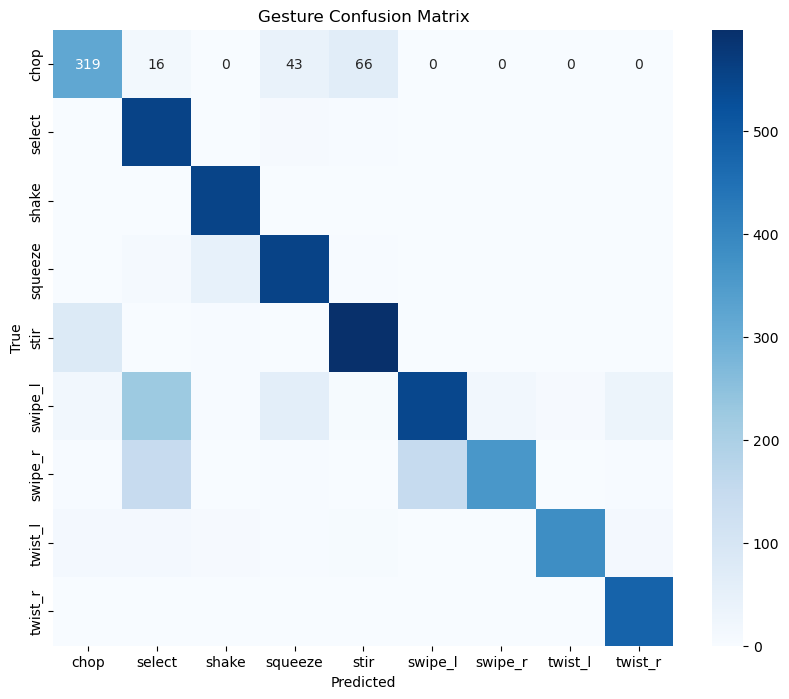

In [34]:
def evaluate_final_model(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.transpose(1, 2).to(device)
            
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_labels.numpy())
    
    # Print metrics
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"\nOverall Test Accuracy: {accuracy * 100:.2f}%")
    print("-" * 30)

    with open("v2/gesture_map.json", "r") as file:
        gesture_map = json.load(file)

    # print(classification_report(all_labels, all_preds, target_names=gesture_map.keys()))
    report_text = classification_report(
        all_labels, all_preds, target_names=gesture_map.keys(), digits=4, zero_division=0
    )
    report_dict = classification_report(
        all_labels, all_preds, target_names=gesture_map.keys(), output_dict=True, zero_division=0
    )

    print(report_text)
    print(f"Macro avg    | Precision: {report_dict['macro avg']['precision']:.6f} | Recall: {report_dict['macro avg']['recall']:.6f} | F1: {report_dict['macro avg']['f1-score']:.6f}")
    print(f"Weighted avg | Precision: {report_dict['weighted avg']['precision']:.6f} | Recall: {report_dict['weighted avg']['recall']:.6f} | F1: {report_dict['weighted avg']['f1-score']:.6f}")
    
    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=gesture_map.keys(), yticklabels=gesture_map.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Gesture Confusion Matrix')
    plt.show()

    return all_preds, all_labels
    
batch_size = study.best_params['batch_size']
test_ds = GestureWindowDatasetAugmented(data_folder_path, test_labels, stride=5)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
all_preds, all_labels = evaluate_final_model(final_model, test_loader)

In [17]:
### RETRAIN WITH IMPROVED CLASS WEIGHTS

# Derive weights from both F1 and precision-vs-recall balance.
# If precision >> recall (under-predicted), weight goes up.
# If recall >> precision (over-predicted), weight goes down.
with open("v2/gesture_map.json", "r") as f:
    gesture_map = json.load(f)
gesture_names = list(gesture_map.keys())

report = classification_report(
    all_labels, all_preds, target_names=gesture_names, output_dict=True, zero_division=0
)

eps = 1e-6
raw_weights = []
per_class_precision = []
per_class_recall = []
per_class_f1 = []

for name in gesture_names:
    p = report[name]["precision"]
    r = report[name]["recall"]
    f1 = report[name]["f1-score"]

    # Base: weak F1 gets higher weight
    base = 1.0 / (f1 + 0.15)

    # Balance term: >1 for under-predicted classes, <1 for over-predicted classes
    balance = np.sqrt((p + eps) / (r + eps))

    raw = base * balance
    raw_weights.append(raw)
    per_class_precision.append(p)
    per_class_recall.append(r)
    per_class_f1.append(f1)

class_weights_v2_improved = np.array(raw_weights, dtype=np.float32)
class_weights_v2_improved = np.clip(class_weights_v2_improved, 0.55, 1.80)
class_weights_v2_improved = class_weights_v2_improved / class_weights_v2_improved.mean()

print("\nUPDATED CLASS WEIGHTS (for next training):")
print(f"\n{'Gesture':<12} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'OldW':<6} | {'NewW':<6} | Delta")
print("-" * 90)

old_weights = GESTURE_WEIGHTS.cpu().numpy()
for i, name in enumerate(gesture_names):
    old_w = float(old_weights[i])
    new_w = float(class_weights_v2_improved[i])
    p = per_class_precision[i]
    r = per_class_recall[i]
    f1 = per_class_f1[i]
    delta = new_w - old_w
    print(f"{name:<12} | {p:<6.2f} | {r:<6.2f} | {f1:<6.2f} | {old_w:<6.2f} | {new_w:<6.2f} | {delta:+.2f}")

print()
print(class_weights_v2_improved.round(3).tolist())
GESTURE_WEIGHTS = torch.tensor(class_weights_v2_improved, dtype=torch.float32)
print("Applied new GESTURE_WEIGHTS tensor for subsequent training cells.")


UPDATED CLASS WEIGHTS (for next training):

Gesture      | Prec   | Rec    | F1     | OldW   | NewW   | Delta
------------------------------------------------------------------------------------------
chop         | 0.93   | 0.70   | 0.80   | 1.03   | 1.10   | +0.07
select       | 0.55   | 0.87   | 0.68   | 0.68   | 0.87   | +0.19
shake        | 0.93   | 1.00   | 0.97   | 1.04   | 0.79   | -0.25
squeeze      | 0.86   | 0.97   | 0.91   | 0.92   | 0.81   | -0.11
stir         | 0.88   | 1.00   | 0.94   | 0.93   | 0.79   | -0.15
swipe_l      | 0.69   | 0.51   | 0.58   | 0.90   | 1.44   | +0.54
swipe_r      | 0.80   | 0.49   | 0.61   | 1.11   | 1.52   | +0.41
twist_l      | 0.99   | 0.87   | 0.93   | 1.33   | 0.90   | -0.43
twist_r      | 0.79   | 1.00   | 0.88   | 1.06   | 0.78   | -0.28

[1.1019999980926514, 0.875, 0.7860000133514404, 0.8069999814033508, 0.7870000004768372, 1.4429999589920044, 1.5190000534057617, 0.8980000019073486, 0.7829999923706055]
Applied new GESTURE_WEIGHTS tensor 

### Export model

In [ ]:
VERSION = "2.3"

def export_model(model):
    model.eval()
    torch.save(model.state_dict(), f"cnn_weights.pth")

export_model(final_model)

In [30]:
### EXPORT TEST SET

target_dir = f"../to_ultra96/v{VERSION}/test_set"
os.makedirs(target_dir, exist_ok=True)

all_test_features = []
all_test_labels = []

for features, label in test_ds:
    # Transpose to match HLS (IN_CH,IN_LEN)
    all_test_features.append(features.numpy().T)
    all_test_labels.append(label)

np.save(os.path.join(target_dir, "x_test.npy"), np.array(all_test_features).astype(np.float32))
np.save(os.path.join(target_dir, "y_test.npy"), np.array(all_test_labels))

In [17]:
input_path = "cnn_weights.pth"
output_path = "weights.h"

model_data = torch.load(input_path, map_location='cpu')

def to_cpp(tensor, name):
    flattened = tensor.detach().numpy().flatten()
    cpp_str = f"const data_t {name}[] = {{" + ",".join(map(str, flattened)) + "};"
    return cpp_str

def check_weights():
    print("Checking weights:")
    for key in model_data.keys():
        print(f"{key}: {len(model_data[key].detach().numpy().flatten())}")

def get_weights_header():
    with open(output_path, "w") as f:
        f.write("#ifndef WEIGHT_H\n")
        f.write("#define WEIGHT_H\n")
        f.write('#include "ap_fixed.h"\n')
        f.write('typedef ap_fixed<32, 12> data_t;\n')                       # only data type that can fit our huge CNN logits
        for key in model_data.keys():
            f.write(to_cpp(model_data[key], key.replace(".", "_")) + "\n")
        f.write('#endif\n')
    print(f"Weights saved to {output_path}")

check_weights()
get_weights_header()

Checking weights:
conv_block.0.weight: 6720
conv_block.0.bias: 32
conv_block.3.weight: 6144
conv_block.3.bias: 64
fc.weight: 576
fc.bias: 9
Weights saved to weights.h


### Validation against Vitis HLS

In [ ]:
### LOAD MODEL

loaded_model = CNN1DClassifier(input_size=IN_CH, num_classes=NUM_CLASSES)
loaded_model.load_state_dict(
    torch.load(f"cnn_weights.pth", map_location=torch.device('cpu'))
)
loaded_model.eval()

CNN1DClassifier(
  (conv_block): Sequential(
    (0): Conv1d(30, 32, kernel_size=(7,), stride=(1,))
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,))
    (4): LeakyReLU(negative_slope=0.1)
    (5): AdaptiveAvgPool1d(output_size=1)
  )
  (fc): Linear(in_features=64, out_features=9, bias=True)
)

In [ ]:
### PREPARE DATA FOR VITIS HLS TESTBENCH
# WINDOW_SIZE changes this

def export_test_sample(csv_file_path, ver=VERSION):
    df = pd.read_csv(csv_file_path, header=None, names=COL_NAMES_V2)
    raw_data = df.values
    processed_data = process_raw_signal(raw_data)
    
    T, F = processed_data.shape
    if T < WINDOW_SIZE:
        padding = np.zeros((WINDOW_SIZE - T, F))
        processed_data = np.vstack([processed_data, padding])
    
    window_raw = processed_data[0:WINDOW_SIZE].copy()
    window_feat = engineer_features_v2(window_raw)
    
    # Convert to Channels-First for Vitis HLS
    hls_ready = window_feat.T               # (IN_CH, IN_LEN)
    flattened = hls_ready.flatten()
    
    filename = csv_file_path.split("/")[-1]
    output_path = f"vitis_hls_sample/sample_{filename}"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, "w") as f:
        for val in flattened:
            f.write(f"{val:.8f}\n")
            
    return torch.tensor(hls_ready).unsqueeze(0) # For checking in Python

files_to_export = [
    "chop_1.txt",
    # "knead_1.txt",
    "select_1.txt",
    "shake_1.txt",
    "squeeze_1.txt",
    "stir_1.txt",
    "swipe_l_1.txt",
    "swipe_r_1.txt",
    "twist_l_1.txt",
    "twist_r_1.txt"
]

for file in files_to_export:
    sample_tensor = export_test_sample(f"training_dataset_clean/{file}")
    with torch.no_grad():
        py_output = loaded_model(sample_tensor)
        clean_output = ",".join(f"{x:.3f}" for x in py_output.flatten().tolist())
        print(f"{{{clean_output}}},")

{-0.179,-6.369,-2.402,-4.325,-3.797,-4.423,-3.974,-5.640,-3.856},
{-2.920,4.150,-1.604,-0.014,-4.435,-3.228,-1.253,-3.870,-3.212},
{-6.054,-4.288,1.511,-3.832,1.860,-2.661,-3.130,-3.177,-3.354},
{-1.908,-0.581,-2.808,1.454,-2.979,-4.931,-2.893,-3.567,-4.763},
{-1.736,-1.969,-3.741,-0.974,0.581,-3.571,-3.792,-3.753,-5.147},
{-3.007,1.257,-2.573,-2.552,-0.197,2.422,-2.777,-3.425,-1.226},
{-2.772,2.078,-2.865,0.576,-2.686,3.153,-1.348,-2.305,-1.100},
{0.933,0.586,-0.276,0.500,1.781,-0.397,1.760,6.302,-0.786},
{-1.067,-1.848,-3.185,0.040,-2.671,-2.651,-4.812,-3.908,-3.424},
